In [1]:
#needed imports
from collections import OrderedDict
import copy
import logging
import os
import urllib.request
import zipfile
import glob 

from astropy.time import Time
import astropy.units as u
from IPython.display import display, Markdown
from gaiasupdate.epoch_astrometry import GaiaEpochAstrometryArchive
from astropy.table import Table
import numpy as np
import periapsis as p
import matplotlib.pyplot as plt
import pandas as pd

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


Fitting Gaia BH3 with Periapsis

First, we need to grab the data. Data retrieval coutersy of https://github.com/esa/gaia-bhthree/blob/gaia-dr4-prerelease/Gaia-DR4-prerelease_BH3_fit_astrometric_orbit.ipynb

In [2]:
url = "https://anonftp.cosmos.esa.int/pub/GAIA_PUBLIC_DATA/Gaia_DR4/dr4-prerelease/gaia-dr4-prerelease-epoch-astrometry_2026-06-26.zip"

local_dir = os.getcwd()

download_path = os.path.join(local_dir, 'downloaded_file.zip')
extract_path = os.path.join(local_dir, 'extracted_files')

if not os.path.isfile(download_path):

    # Download the file
    urllib.request.urlretrieve(url, os.path.basename(download_path))
   

with zipfile.ZipFile(download_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



epoch_astrometry_file = glob.glob(os.path.join(extract_path, '*.xml'))[0]


table = Table.read(epoch_astrometry_file, format="votable")
epoch_astrometry = table.to_pandas()


In [3]:
name_dict = {'Gaia BH3': 4318465066420528000,
    'HD 114762': 3937211745905473024,
    'Gaia-4': 1457486023639239296}


source_id = name_dict['Gaia BH3'] # for Gaia BH3
# source_id = name_dict['HD 114762'] 
# source_id = name_dict['Gaia-4'] 

m1_MS = 0.76  # Primary star mass for Gaia BH3
target_ra_deg = 294.8278502411 # Right Ascension for Gaia BH3
target_dec_deg = 14.9309190720 # Declination for Gaia BH3


epoch_astrometry_bh3 = epoch_astrometry[epoch_astrometry['source_id'] == source_id]

In [4]:
ea = GaiaEpochAstrometryArchive.from_dataframe(epoch_astrometry_bh3)

# use only data used by the Gaia DR4 core astrometric solution
ea.epoch_data = ea.epoch_data.epochastrometryarchive.filter_on_used_by_agis()

# sort by increasing time
ea.epoch_data.epochastrometryarchive.sort_by_column('obs_time_tcb')

# set auxiliary fields
ea.epoch_data.epochastrometryarchive.set_relative_time() # sets 'relative_time_year','relative_time_day'
ea.epoch_data = ea.epoch_data.epochastrometryarchive.set_scan_angle_derived_columns() # sets 'sin_theta', 'cos_theta', 'sin_theta_time', 'cos_theta_time
ea.epoch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   solution_id                558 non-null    int64  
 1   source_id                  558 non-null    int64  
 2   transit_id                 558 non-null    int64  
 3   ra0                        558 non-null    float64
 4   dec0                       558 non-null    float64
 5   agis_source_excess_noise   558 non-null    float32
 6   obs_time_tcb               558 non-null    int64  
 7   obs_time_bary_corr         558 non-null    float32
 8   scan_pos_angle             558 non-null    float64
 9   zeta                       558 non-null    float32
 10  parallax_factor_al         558 non-null    float32
 11  parallax_factor_ac         558 non-null    float32
 12  colour_factor_al           558 non-null    float64
 13  colour_factor_ac           558 non-null    object 

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)


Grab Data needed for fit

In [5]:
gaia_astrometry = ea.epoch_data.copy()

spsi = gaia_astrometry['sin_theta'].values
cpsi = gaia_astrometry['cos_theta'].values
ti = gaia_astrometry['relative_time_year'].values
plx_factor = gaia_astrometry['parallax_factor_al'].values
x = gaia_astrometry['centroid_pos_al'].values
err = gaia_astrometry['centroid_pos_error_al'].values

We need to now set up the data object and priors for fitting

In [ ]:
# Set up units and initialize GaiaData object
units = {'t':'year', 'x':'mas', 'err':'mas'}
data = p.GaiaData(spsi,cpsi,ti,plx_factor,x,err,units=units,system='1')

# Set up priors for the model parameters
# Prior units must correspond to data object with same dimensionality

priors_lin = {
    'P': p.UniformPrior(0.1,50), # Period, years
    'e': p.UniformPrior(0.0, 0.95), # Eccentricity
    't0': p.UniformPrior(-0.5,0.5), # Tp/P, dimensionless
    'astro_jitter': p.LogUniformPrior(0.001,0.5), # Jitter, mas
    'M1': p.FixedPrior(m1_MS)
}

Set up the Fitter

In [8]:
fitter1 = p.MCMCLinearFitter(
    nwalkers=80,
    niter=10000,
    sampled_params = ['P', 'e', 't0', 'astro_jitter'],
    **priors_lin
)
results1 = fitter1.fit(data,rng=np.random.default_rng(42))

100%|██████████| 10000/10000 [06:43<00:00, 24.78it/s]


Check results and fit statistics

In [9]:
stats1,fit_results1 = p.all_stats(results1,data)

{
    "Ess": [
        16713.109072228992,
        16691.175454793967,
        16752.808568743683,
        24588.59410506494
    ],
    "credible_intervals": {
        "A1": {
            "+1sigma": 2.498692760093256,
            "+2sigma": 2.5637674479054096,
            "-1sigma": 2.3760891785285523,
            "-2sigma": 2.3172140012920392
        },
        "B1": {
            "+1sigma": 10.819067016933667,
            "+2sigma": 11.052123947496524,
            "-1sigma": 10.389336021301807,
            "-2sigma": 10.201264457706506
        },
        "F1": {
            "+1sigma": 21.180424492891248,
            "+2sigma": 21.783505359600547,
            "-1sigma": 20.128256172243134,
            "-2sigma": 19.658298604124955
        },
        "G1": {
            "+1sigma": -16.631279345937212,
            "+2sigma": -16.29129330666229,
            "-1sigma": -17.385005056898688,
            "-2sigma": -17.821173948133325
        },
        "M2": {
            "+1sigma": 35.2614

Generate visualizations for orbit and fit properties

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


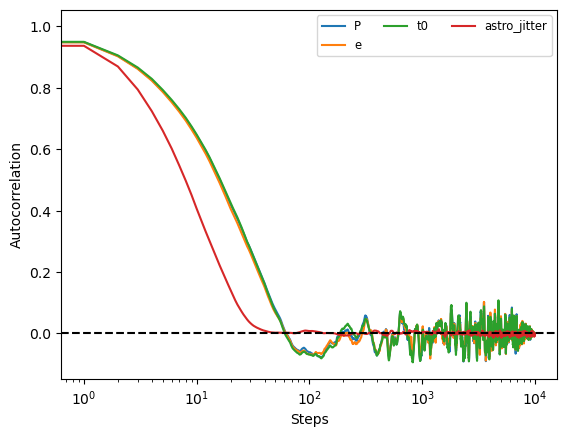

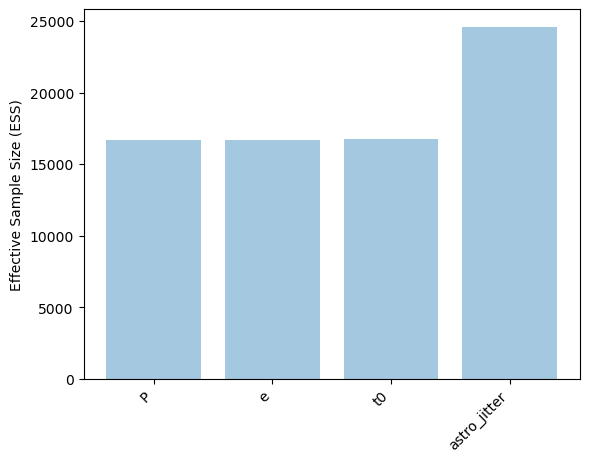

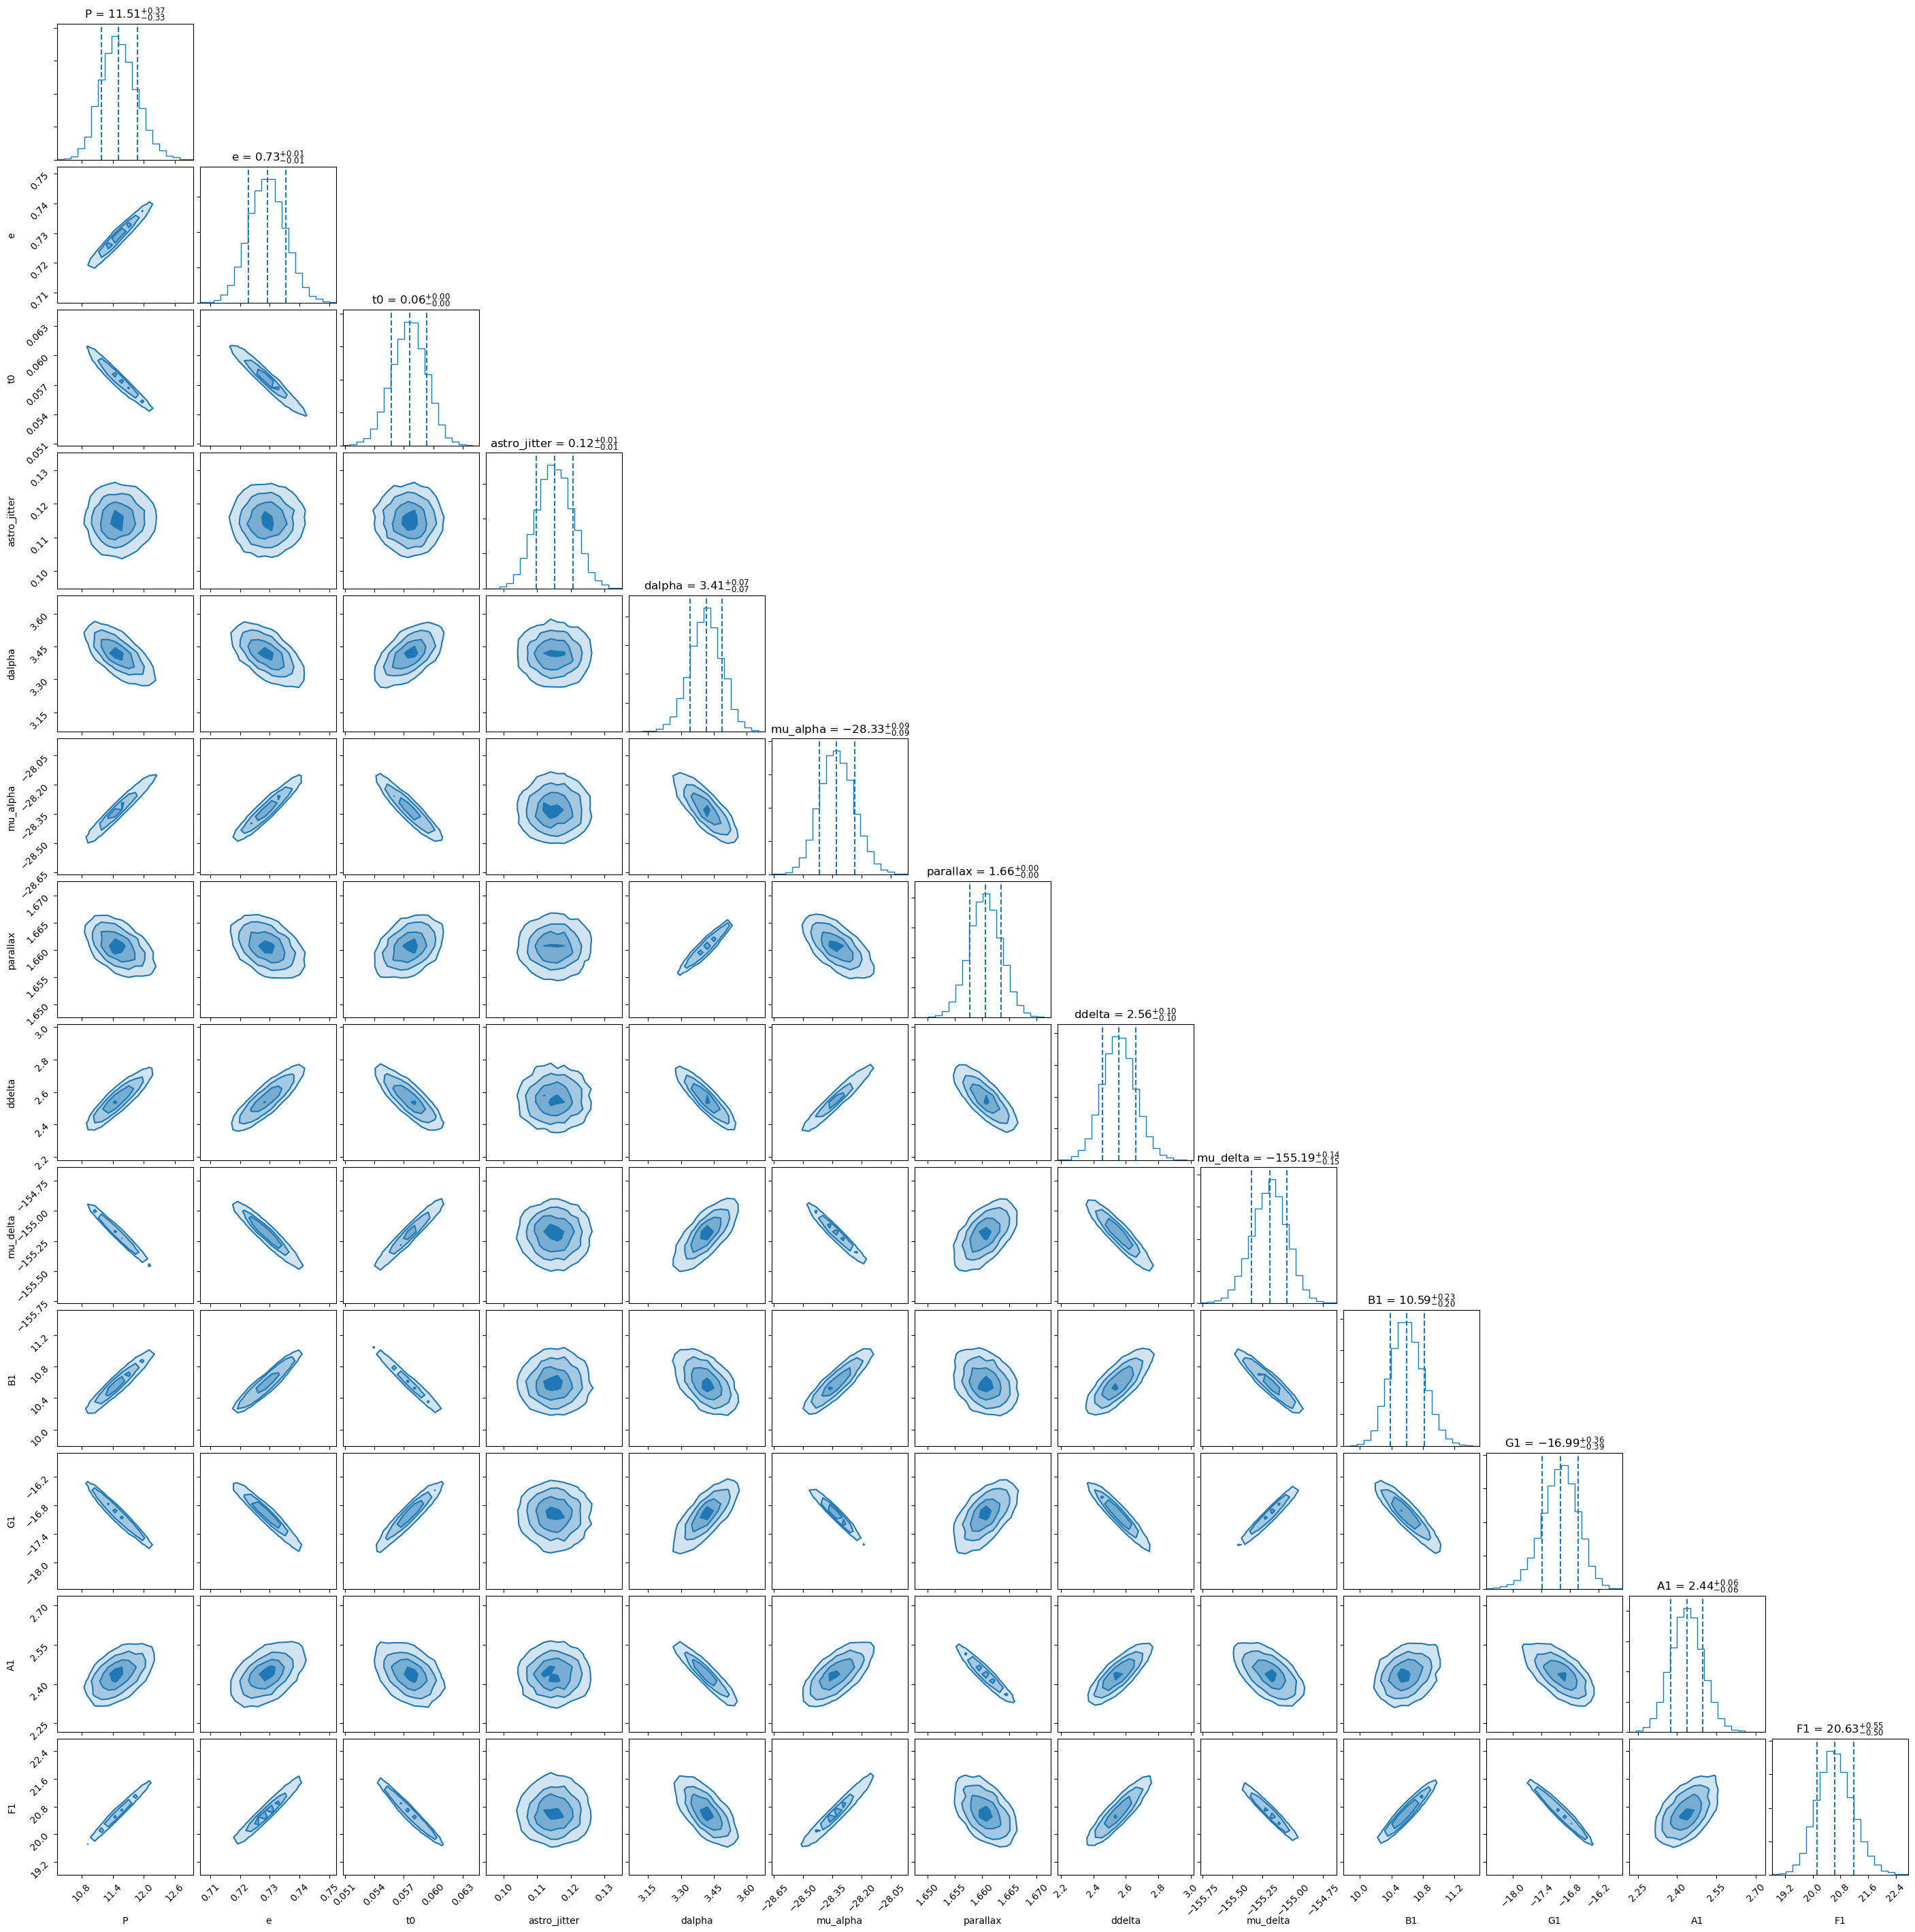

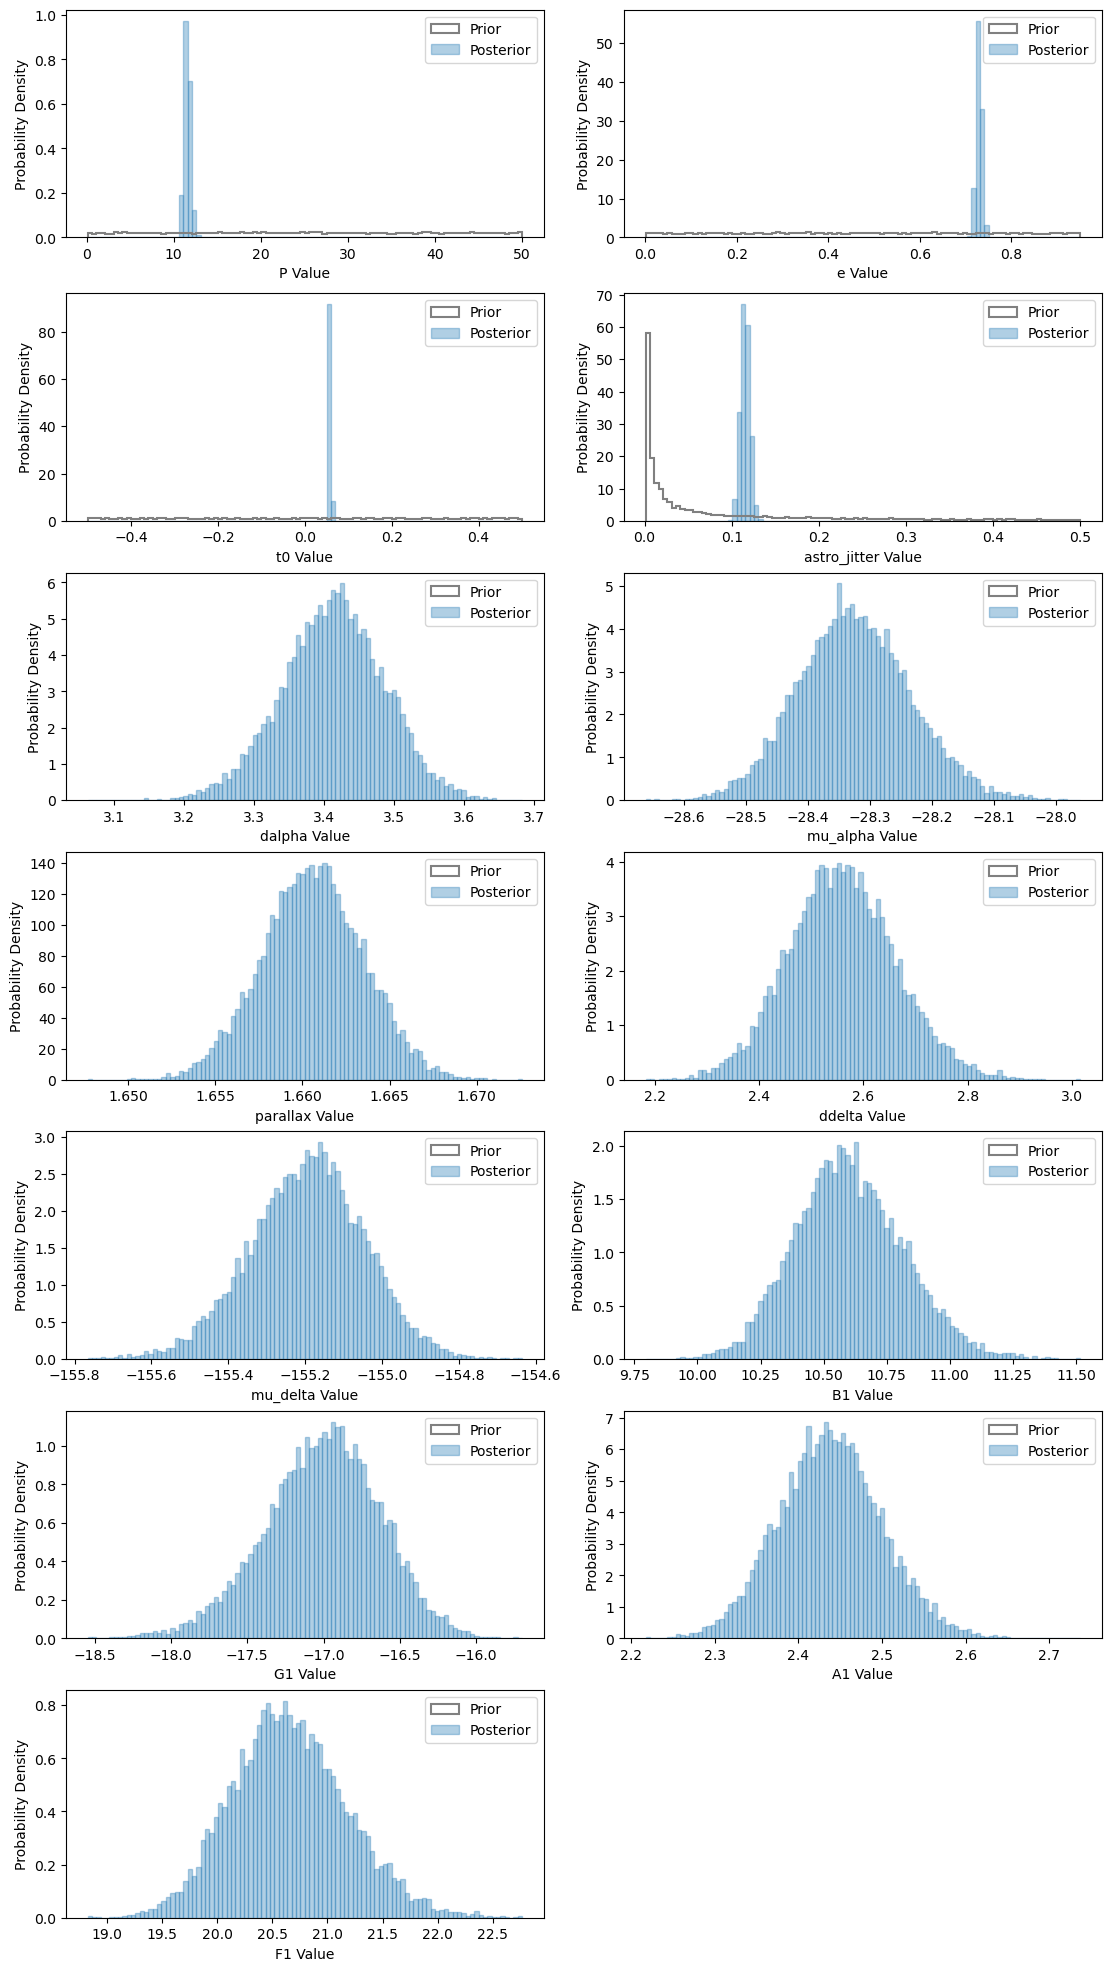

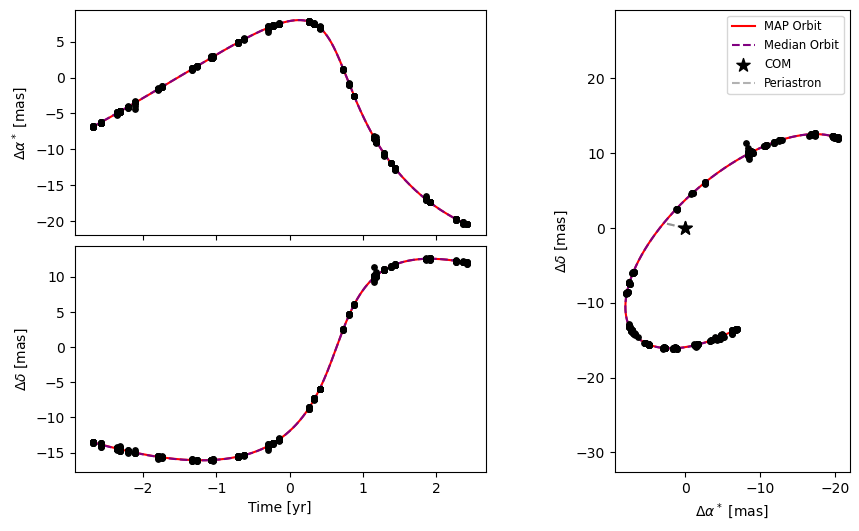

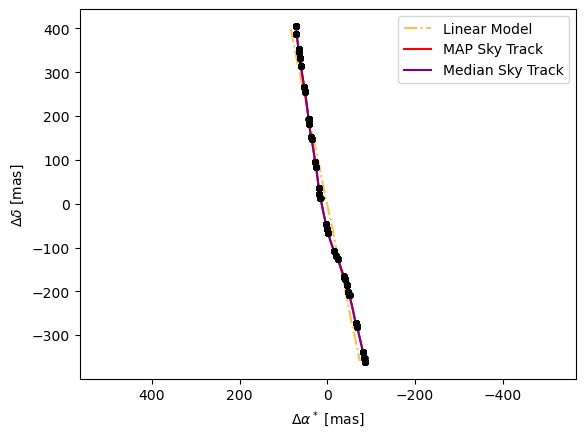

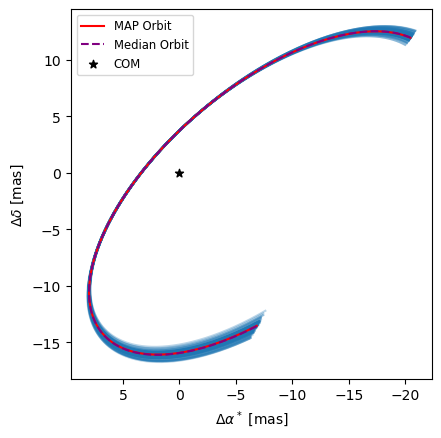

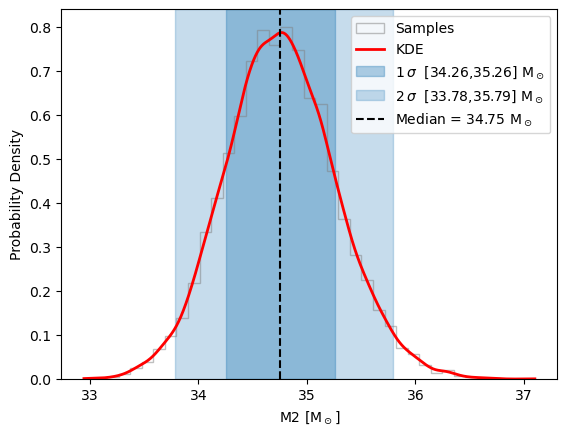

In [10]:
p.all_plots(results1,data)

Now let's do a Joint fit with RVs

In [11]:
df = pd.read_csv('data/gaiabh3/gaiabh3_rv.tsv', comment='#', sep=r'\s+', 
                 names=['TransitID', 'ObsTime', 'RV', 'e_RV'], skiprows=37)

print(df.head())

           TransitID       ObsTime      RV  e_RV
0  22989619581449144  2.457010e+06 -338.62  1.42
1  22993711812243969  2.457010e+06 -341.08  1.70
2  27565894819405940  2.457093e+06 -338.73  1.41
3  27569987068420645  2.457093e+06 -340.63  1.43
4  29624665178404300  2.457130e+06 -335.28  2.20


In [12]:
DR4_REF_JD = 2457936.375 #2017.5

# Convert raw RV Julian Dates into relative years from 2017.5
df['relative_time_year'] = (df['ObsTime'] - DR4_REF_JD) / 365.25


In [ ]:
rv_t = df['relative_time_year'].values
rv = df['RV'].values
rv_err = df['e_RV'].values

units_rv = {'t':'year', 'rv':'km/s', 'rv_err':'km/s'}

rv_data = p.RadialVelocityData(rv_t, rv, rv_err, units=units_rv, system='1')

Now we can initialize the JointData

In [14]:
datasets = [data, rv_data]
joint = p.JointData(datasets)

In [15]:
#Linear fit using same priors as before

fitter_joint = p.MCMCLinearFitter(
    nwalkers=60,
    niter=10000,
    sampled_params = ['P', 'e', 't0', 'astro_jitter'],
    **priors_lin
)

results_joint = fitter_joint.fit(joint,rng=np.random.default_rng(42))

  1%|          | 81/10000 [00:02<05:58, 27.68it/s]

100%|██████████| 10000/10000 [06:01<00:00, 27.65it/s]


In [16]:
stats_joint,fit_results_joint = p.all_stats(results_joint,joint)

{
    "Ess": [
        12073.2094208736,
        12195.183819639906,
        12071.539593008873,
        15965.693360674242
    ],
    "credible_intervals": {
        "A1": {
            "+1sigma": 2.5023276362478306,
            "+2sigma": 2.5614750436013054,
            "-1sigma": 2.382913499548083,
            "-2sigma": 2.327926991049163
        },
        "B1": {
            "+1sigma": 10.83353911267943,
            "+2sigma": 11.056652263000231,
            "-1sigma": 10.433124574927835,
            "-2sigma": 10.249837226380967
        },
        "F1": {
            "+1sigma": 21.221631261521352,
            "+2sigma": 21.755263930198833,
            "-1sigma": 20.252346806442116,
            "-2sigma": 19.811938482977418
        },
        "G1": {
            "+1sigma": -16.719841604814928,
            "+2sigma": -16.41524781074551,
            "-1sigma": -17.415148922958675,
            "-2sigma": -17.794212052136483
        },
        "M2": {
            "+1sigma": 35.3066283

/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/uufs/astro.utah.edu/common/home/u1383373/software/pkg/miniforge3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


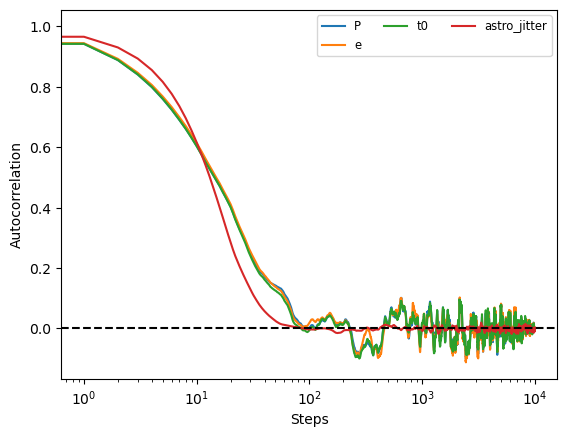

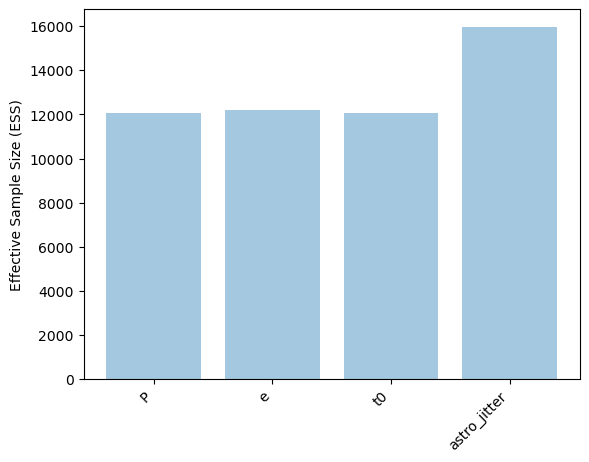

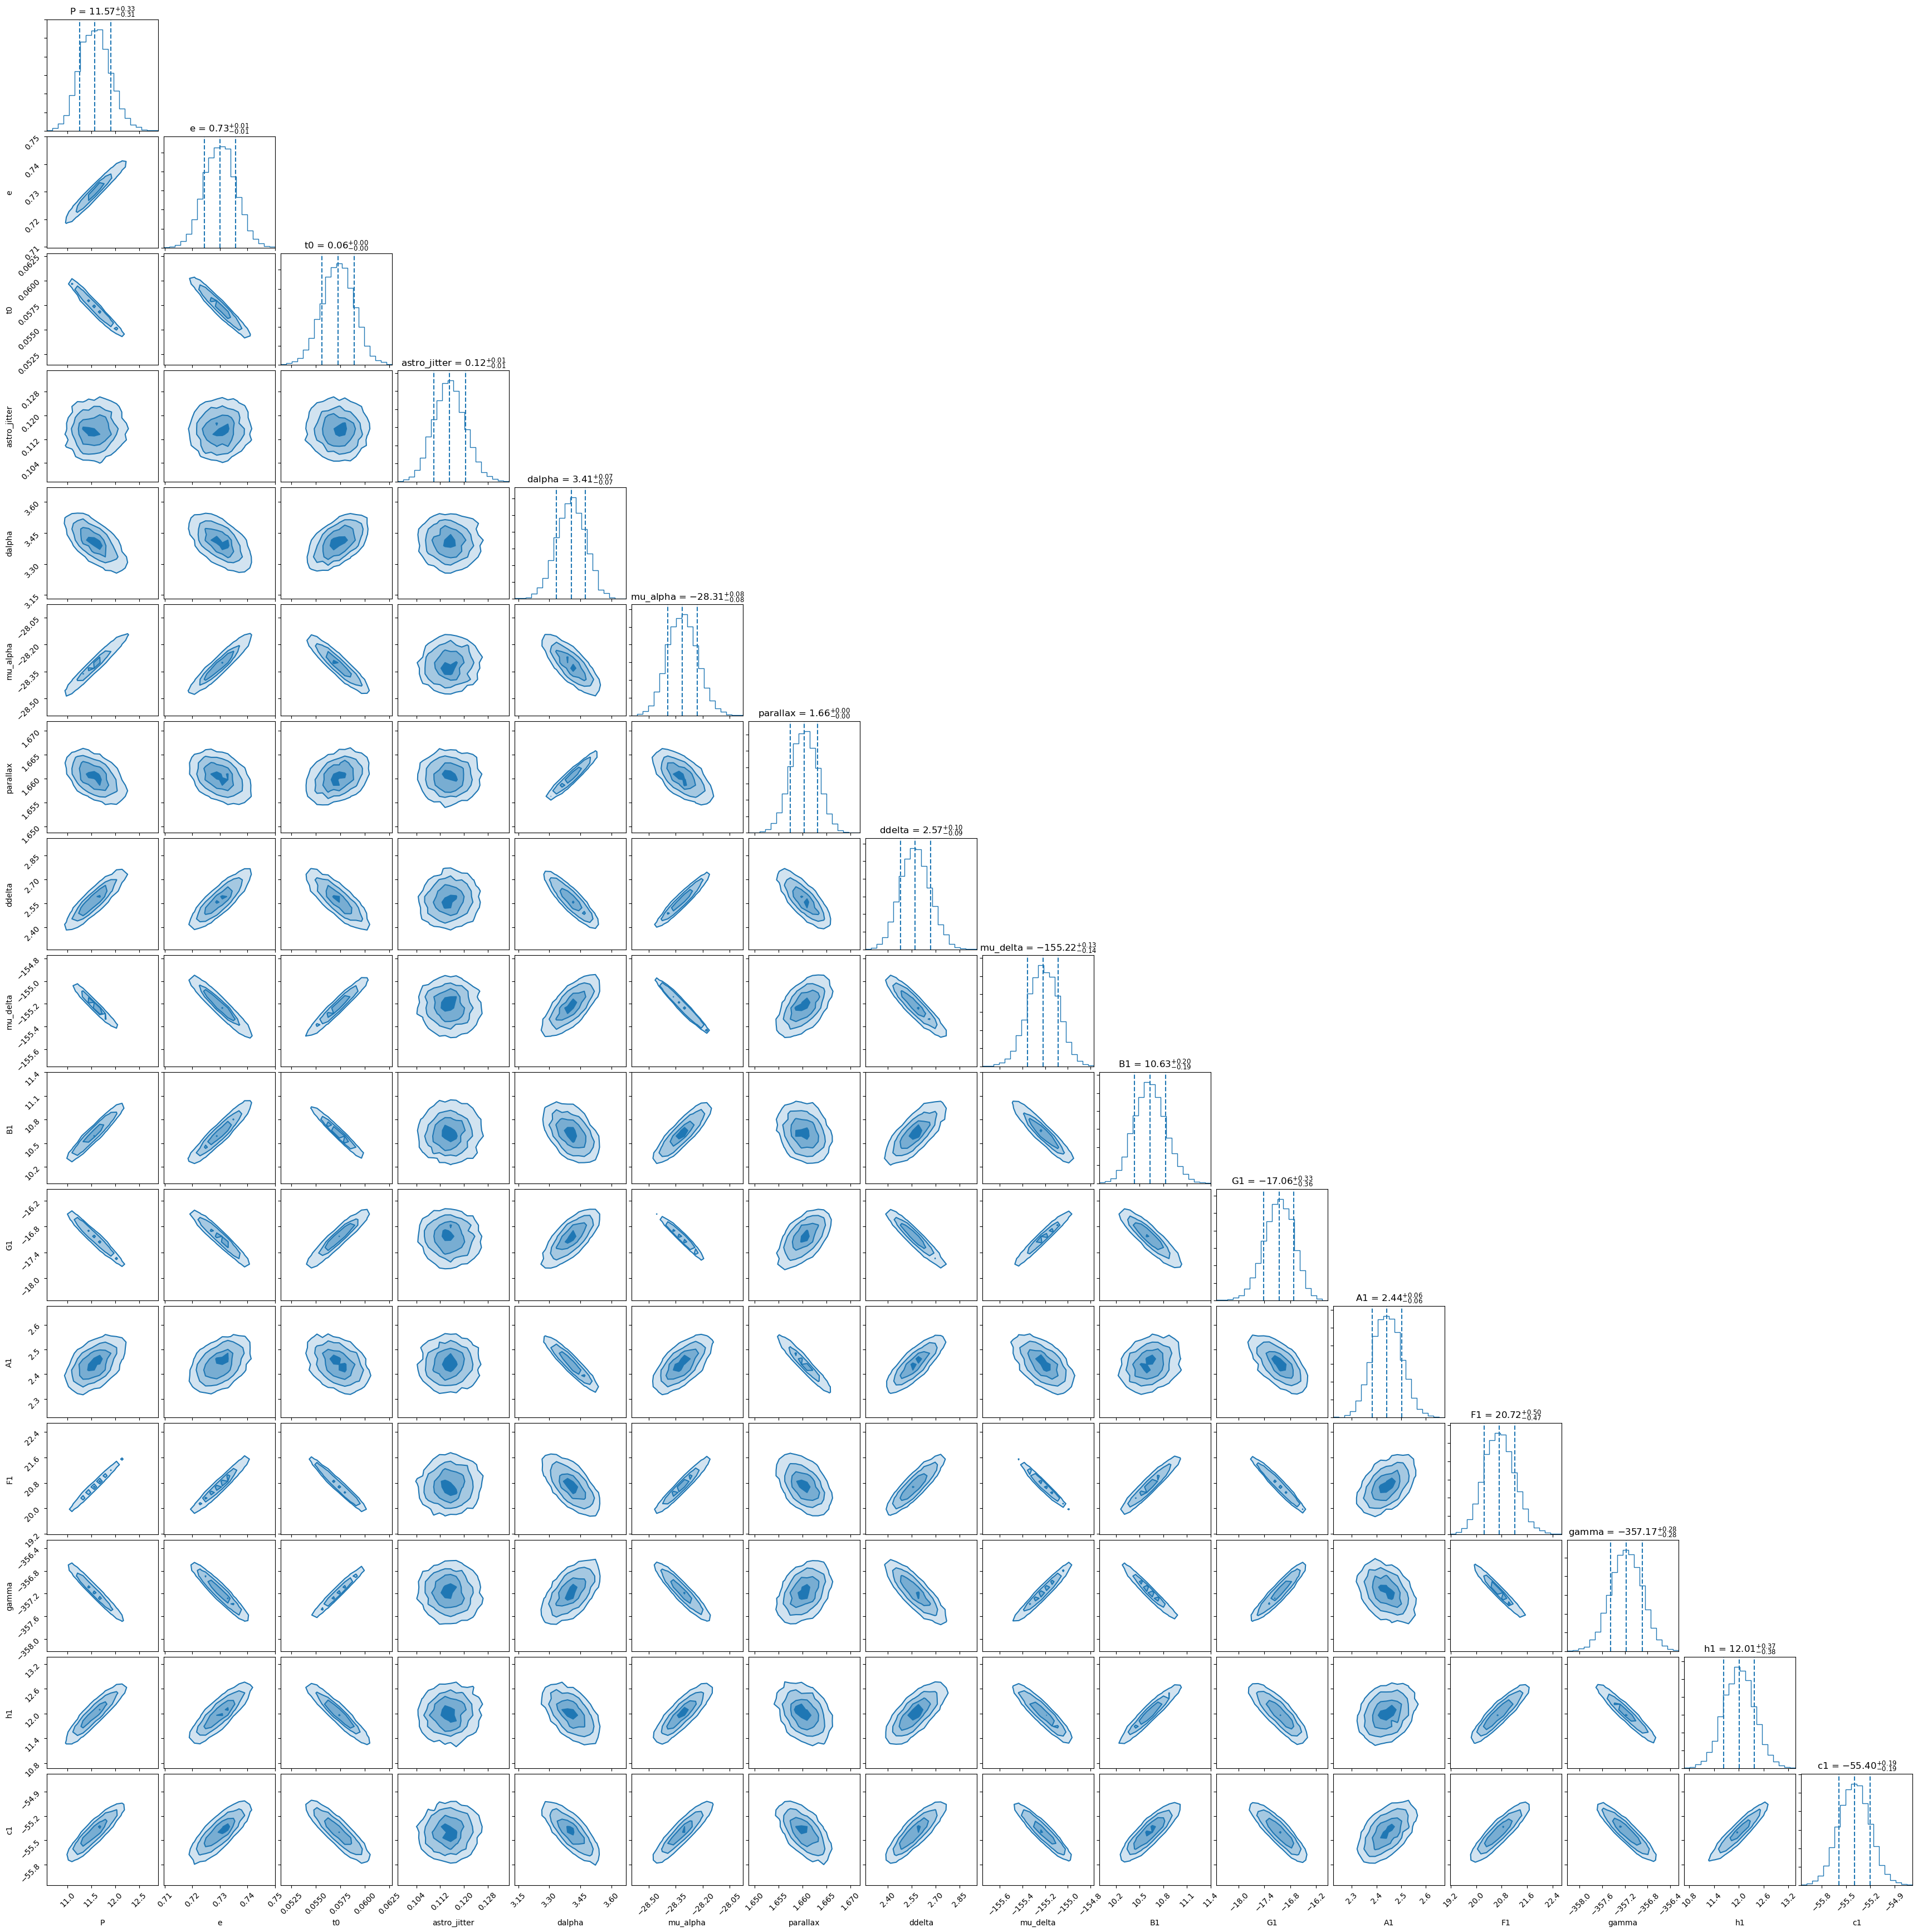

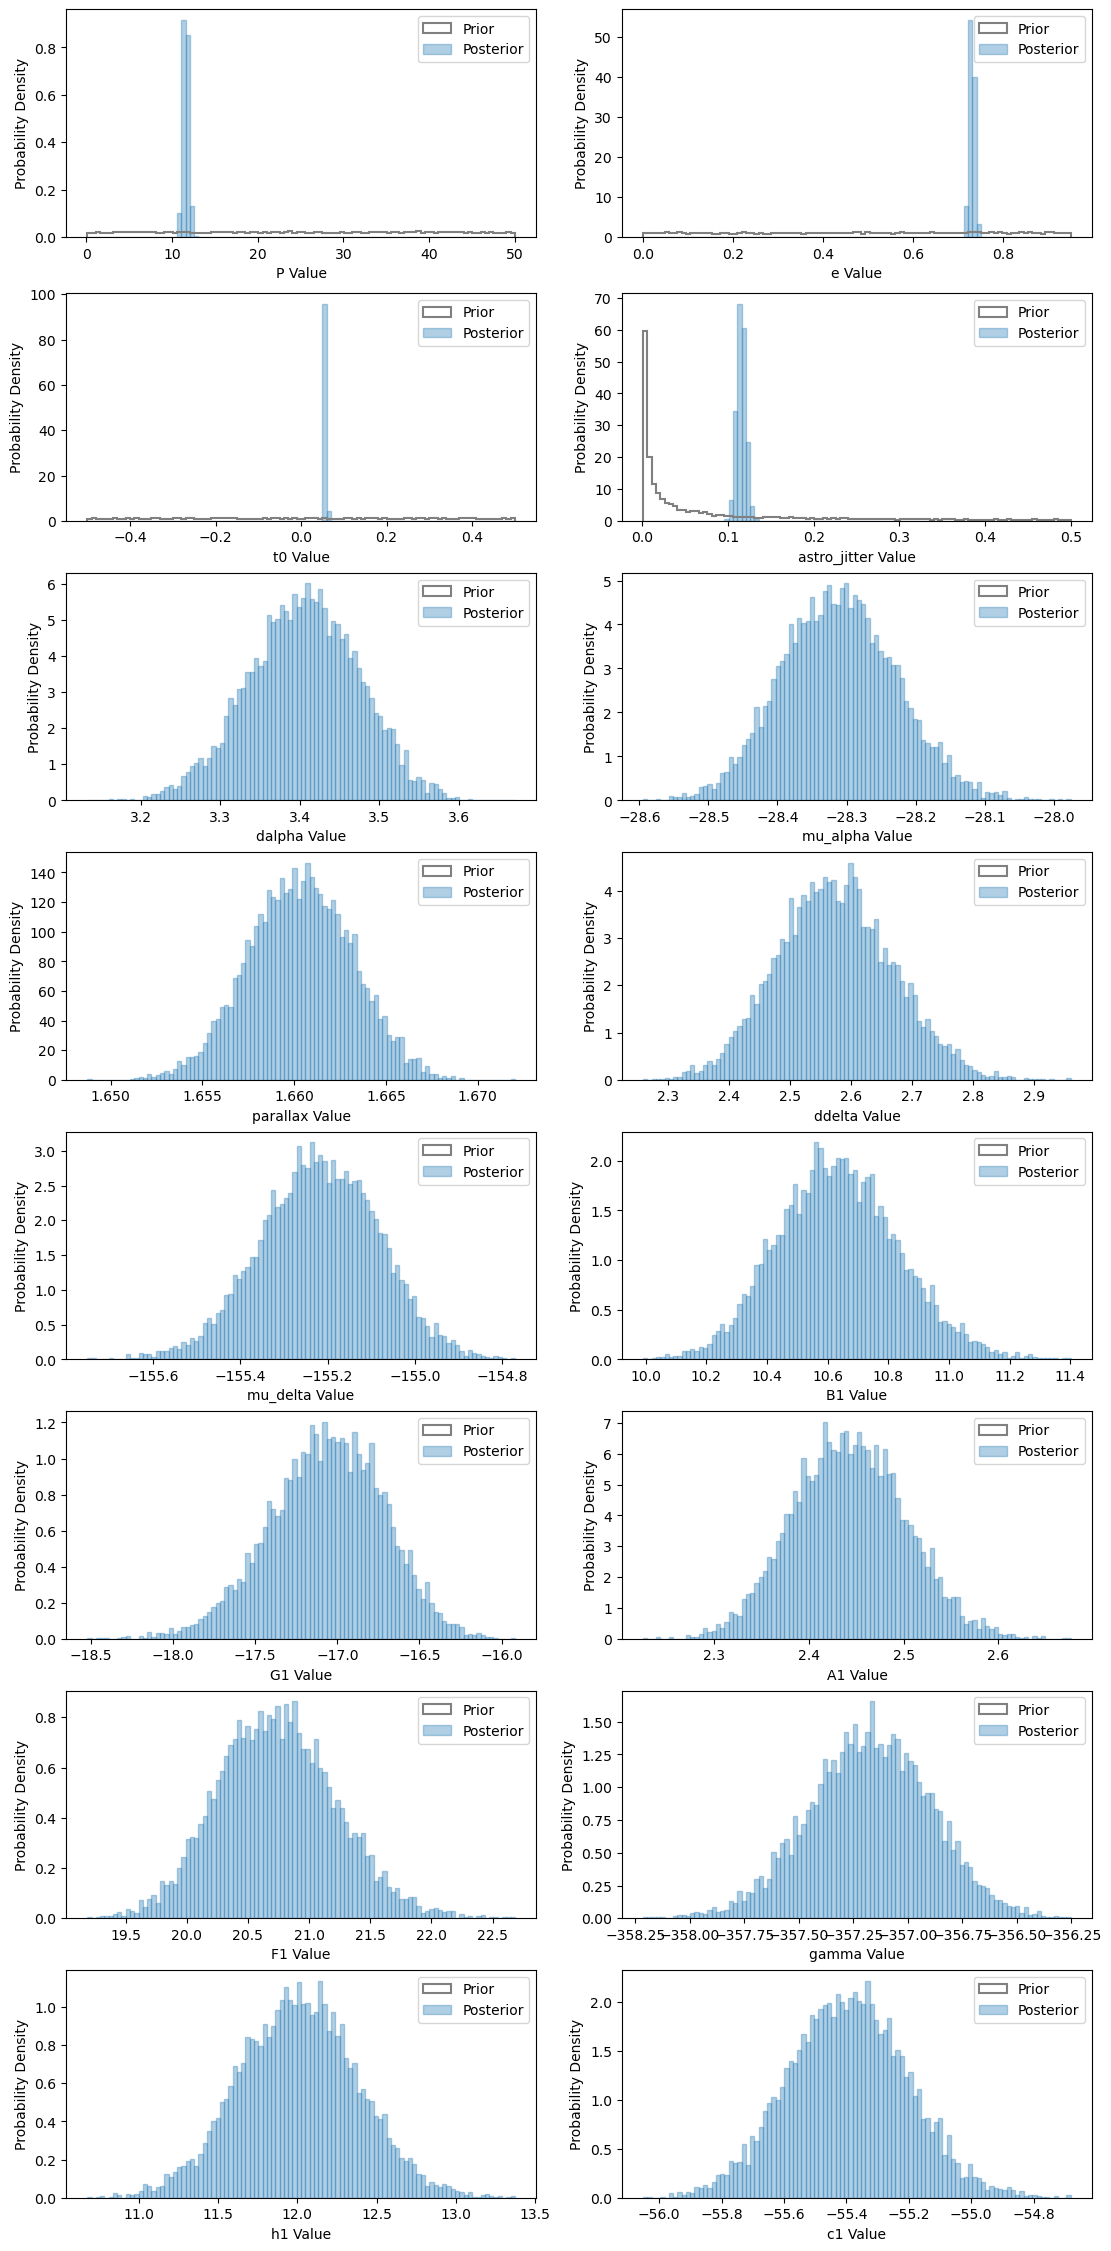

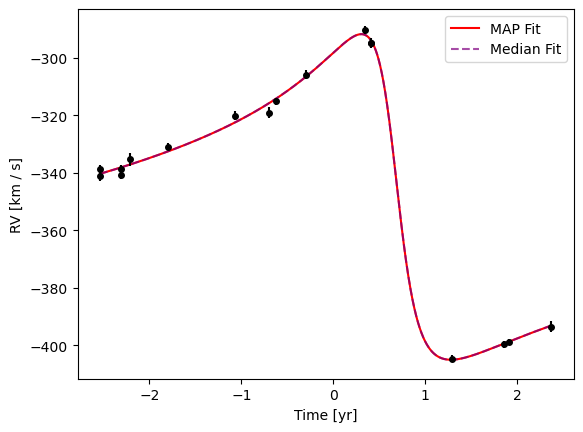

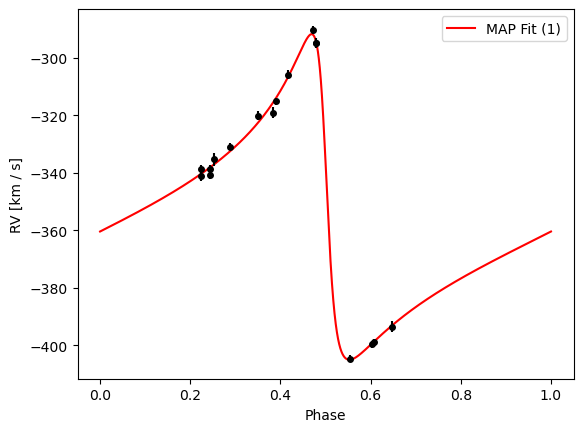

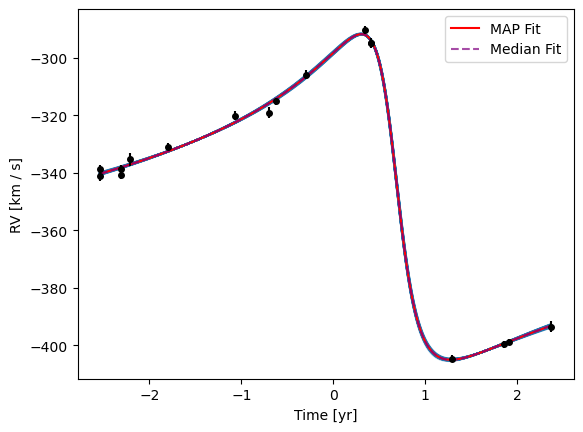

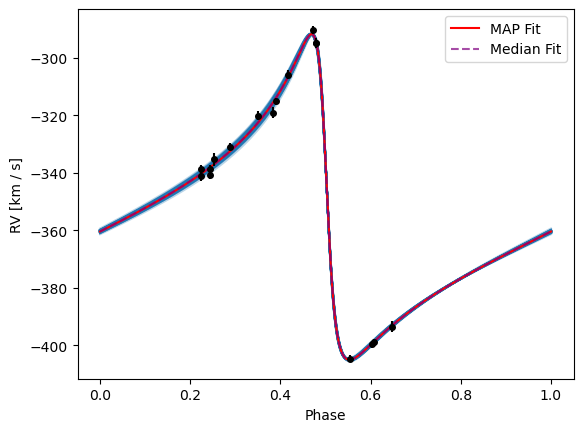

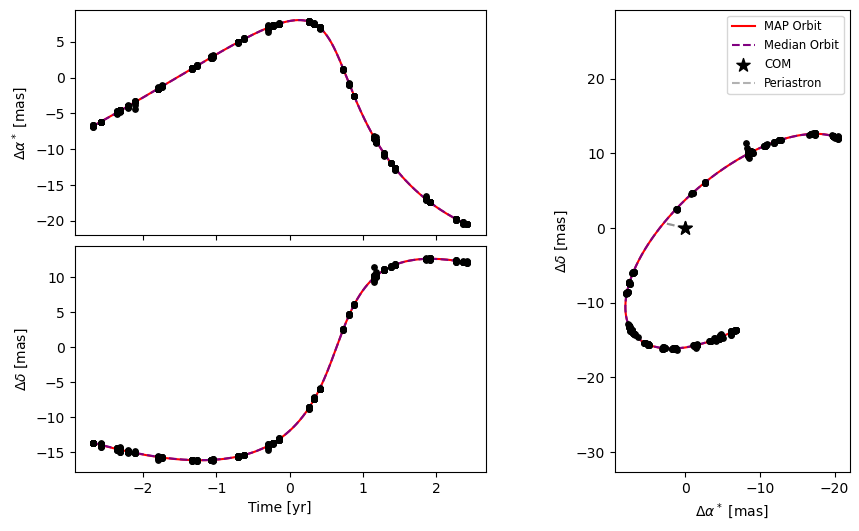

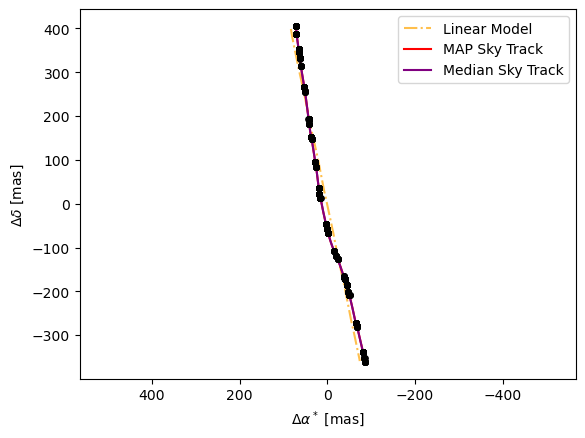

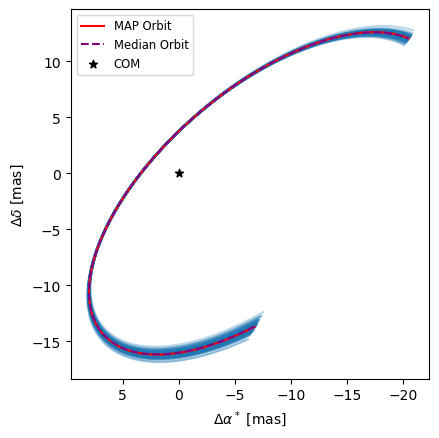

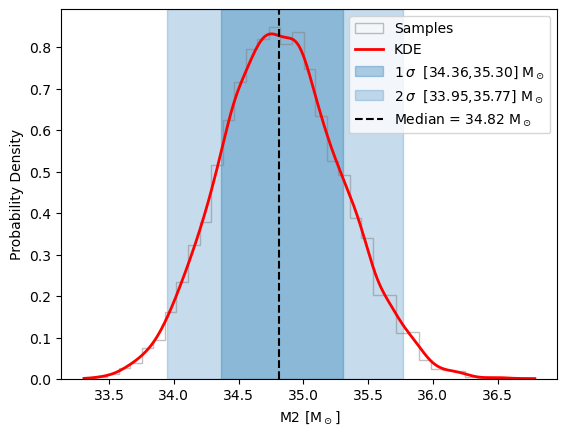

In [17]:
p.all_plots(results_joint,joint)